# Scania APS Failure — Data Analysis & Exploratory Data Analysis

## EC5203 Machine Learning

**Project:** Predictive Maintenance of Scania Truck Air Pressure Systems Using Supervised Machine Learning

**Team:** Team AirBrake

### Member 1 Responsibilities
- Dataset understanding
- Data quality analysis
- Missing-value analysis
- Class distribution analysis
- Feature analysis
- Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import pandas as pd

data_path = "../data/aps_failure_training_set.csv"

df = pd.read_csv(
    data_path,
    skiprows=20,
    na_values="na"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (60000, 171)


In [3]:
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,703300.0,755876.0,0.0,5374.0,2108.0,4114.0,12348.0,615248.0,5526276.0,2378.0,4.0,0.0,0.0,2328746.0,1022304.0,415432.0,287230.0,310246.0,681504.0,1118814.0,3574.0,0.0,0.0,6700214.0,0.0,10.0,108.0,50.0,2551696.0,97518.0,947550.0,799478.0,330760.0,353400.0,299160.0,305200.0,283680.0,NaN,NaN,NaN,178540.0,76698.08,6700214.0,6700214.0,6599892.0,43566.0,68656.0,54064.0,638360.0,6167850.0,1209600.0,246244.0,2.0,96.0,0.0,5245752.00,0.0,916567.68,6.0,1924.0,0.0,0.0,0.0,118196.0,1309472.0,3247182.0,1381362.0,98822.0,11208.0,1608.0,220.0,240.0,6700214.0,NaN,10476.0,1226.0,267998.0,521832.0,428776.0,4015854.0,895240.0,26330.0,118.0,0.0,532.0,734.0,4122704.0,51288.0,0.0,532572.0,0.0,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,1996924.0,99560.0,0.0,7336.0,7808.0,13776.0,13086.0,1010074.0,1873902.0,14726.0,6.0,0.0,0.0,1378576.0,447166.0,199512.0,154298.0,137280.0,138668.0,165908.0,229652.0,87082.0,4708.0,3646660.0,86.0,454.0,364.0,350.0,1393352.0,49028.0,688314.0,392208.0,341420.0,359780.0,366560.0,NaN,NaN,NaN,NaN,NaN,6700.0,33057.51,3646660.0,3646660.0,3582034.0,17733.0,260120.0,115626.0,6900.0,2942850.0,1209600.0,0.0,NaN,NaN,NaN,2291079.36,0.0,643536.96,0.0,0.0,0.0,0.0,38.0,98644.0,1179502.0,1286736.0,336388.0,36294.0,5192.0,56.0,NaN,0.0,3646660.0,NaN,6160.0,796.0,164860.0,350066.0,272956.0,1837600.0,301242.0,9148.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,239798.0,1450312.0,0.0,1620.0,1156.0,1228.0,34250.0,1811606.0,710672.0,34.0,0.0,0.0,0.0,790690.0,672026.0,332340.0,254892.0,189596.0,135758.0,103552.0,81666.0,46.0,0.0,2673338.0,128.0,202.0,576.0,4.0,1234132.0,28804.0,160176.0,139730.0,137160.0,13064

In [4]:
print("Number of features:", df.shape[1] - 1)

print("\nData types:")
print(df.dtypes.value_counts())

Number of features: 170

Data types:
float64    169
str          1
int64        1
Name: count, dtype: int64


In [5]:
class_counts = df["class"].value_counts()

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(df["class"].value_counts(normalize=True) * 100)

Class counts:
class
neg    59000
pos     1000
Name: count, dtype: int64

Class percentages:
class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64


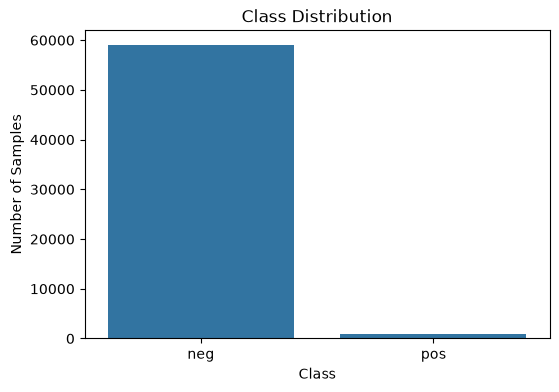

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="class")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [7]:
missing_count = df.isnull().sum()

missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

print("Number of features with missing values:", len(missing_count))
print("\nTop 20 features with missing values:")
print(missing_count.head(20))

Number of features with missing values: 169

Top 20 features with missing values:
br_000    49264
bq_000    48722
bp_000    47740
bo_000    46333
cr_000    46329
ab_000    46329
bn_000    44009
bm_000    39549
bl_000    27277
bk_000    23034
ad_000    14861
cf_000    14861
ch_000    14861
cg_000    14861
co_000    14861
cy_000    13808
cz_000    13808
cx_000    13808
cv_000    13808
ct_000    13808
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

print("Top 20 features by missing-value percentage:")
print(missing_percentage.head(20))

Top 20 features by missing-value percentage:
br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
cr_000    77.215000
ab_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
ad_000    24.768333
cf_000    24.768333
ch_000    24.768333
cg_000    24.768333
co_000    24.768333
cy_000    23.013333
cz_000    23.013333
cx_000    23.013333
cv_000    23.013333
ct_000    23.013333
dtype: float64


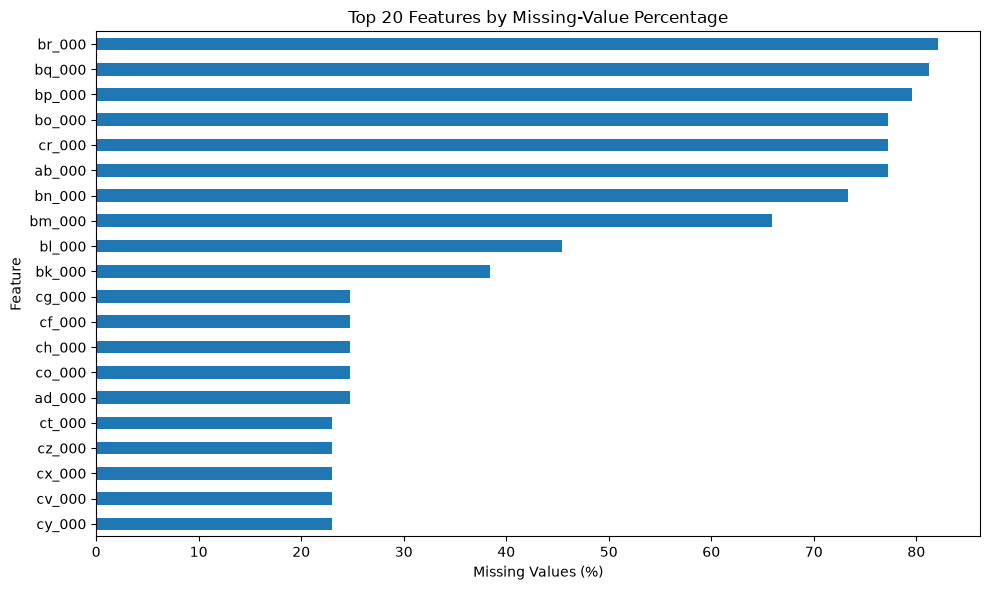

In [9]:
plt.figure(figsize=(10, 6))

missing_percentage.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Features by Missing-Value Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [10]:
row_missing = df.isnull().sum(axis=1)

print("Rows with at least one missing value:", (row_missing > 0).sum())

print(
    "Percentage of rows with at least one missing value:",
    (row_missing > 0).mean() * 100
)

print("Maximum missing values in a single row:", row_missing.max())

Rows with at least one missing value: 59409
Percentage of rows with at least one missing value: 99.015
Maximum missing values in a single row: 168


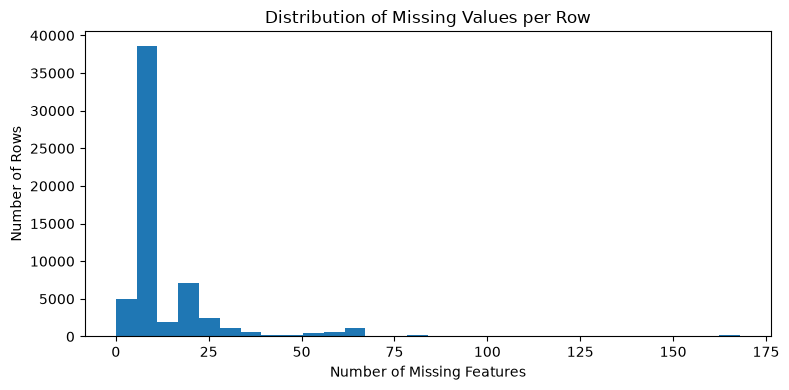

In [11]:
plt.figure(figsize=(8, 4))

plt.hist(row_missing, bins=30)

plt.title("Distribution of Missing Values per Row")
plt.xlabel("Number of Missing Features")
plt.ylabel("Number of Rows")

plt.tight_layout()
plt.show()

In [12]:
feature_stats = df.drop(columns=["class"]).describe().T

print(feature_stats.head(20))

          count          mean           std  min      25%        50%  \
aa_000  60000.0  5.933650e+04  1.454301e+05  0.0    834.0    30776.0   
ab_000  13671.0  7.131885e-01  3.478962e+00  0.0      0.0        0.0   
ac_000  56665.0  3.560143e+08  7.948749e+08  0.0     16.0      152.0   
ad_000  45139.0  1.906206e+05  4.040441e+07  0.0     24.0      126.0   
ae_000  57500.0  6.819130e+00  1.615434e+02  0.0      0.0        0.0   
af_000  57500.0  1.100682e+01  2.097926e+02  0.0      0.0        0.0   
ag_000  59329.0  2.216364e+02  2.047846e+04  0.0      0.0        0.0   
ag_001  59329.0  9.757223e+02  3.420053e+04  0.0      0.0        0.0   
ag_002  59329.0  8.606015e+03  1.503220e+05  0.0      0.0        0.0   
ag_003  59329.0  8.859128e+04  7.617312e+05  0.0      0.0        0.0   
ag_004  59329.0  4.370966e+05  2.374282e+06  0.0    308.0     3672.0   
ag_005  59329.0  1.108374e+06  3.262607e+06  0.0  13834.0   176020.0   
ag_006  59329.0  1.657818e+06  3.909384e+06  0.0  10608.0   9303

In [13]:
Q1 = df.drop(columns=["class"]).quantile(0.25)
Q3 = df.drop(columns=["class"]).quantile(0.75)

IQR = Q3 - Q1

outlier_counts = (
    ((df.drop(columns=["class"]) < (Q1 - 1.5 * IQR)) |
     (df.drop(columns=["class"]) > (Q3 + 1.5 * IQR)))
    .sum()
)

outlier_counts = outlier_counts.sort_values(ascending=False)

print("Top 20 features by number of potential outliers:")
print(outlier_counts.head(20))

Top 20 features by number of potential outliers:
az_007    14235
dr_000    13007
dq_000    12870
ba_008    12580
cj_000    12540
aj_000    12452
ag_003    12435
ag_009    11926
dy_000    11867
ba_009    11582
dx_000    11572
ee_009    11316
al_000    11092
am_0      10825
ac_000    10800
bz_000    10438
cn_002    10348
di_000    10347
az_006     9991
ag_004     9735
dtype: int64


In [14]:
feature_nunique = df.drop(columns=["class"]).nunique()

print("Features with only one unique value:")
print(feature_nunique[feature_nunique == 1])

print("\nNumber of constant features:", (feature_nunique == 1).sum())

Features with only one unique value:
cd_000    1
dtype: int64

Number of constant features: 1


In [15]:
numeric_df = df.drop(columns=["class"])

correlation_matrix = numeric_df.corr()

high_corr_pairs = (
    correlation_matrix.where(
        np.triu(
            np.ones(correlation_matrix.shape), k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("Top 20 highly correlated feature pairs:")
print(high_corr_pairs.head(20))

Top 20 highly correlated feature pairs:
bb_000  bv_000    1.000000
ah_000  bg_000    1.000000
bv_000  cq_000    1.000000
bb_000  cq_000    1.000000
aa_000  bt_000    1.000000
bu_000  cq_000    1.000000
        bv_000    1.000000
bb_000  bu_000    1.000000
cf_000  co_000    1.000000
ad_000  cf_000    1.000000
        co_000    1.000000
bx_000  cc_000    0.996186
al_000  am_0      0.993895
an_000  ao_000    0.992997
ah_000  an_000    0.988375
an_000  bg_000    0.988342
        bb_000    0.988160
        bv_000    0.988147
        cq_000    0.988147
        bu_000    0.988147
dtype: float64


In [17]:
abs_corr = correlation_matrix.abs()

high_corr_pairs_abs = (
    abs_corr.where(
        np.triu(
            np.ones(abs_corr.shape), k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("Top 20 feature pairs by absolute correlation:")
print(high_corr_pairs_abs.head(20))

Top 20 feature pairs by absolute correlation:
bb_000  bv_000    1.000000
ah_000  bg_000    1.000000
bv_000  cq_000    1.000000
bb_000  cq_000    1.000000
aa_000  bt_000    1.000000
bu_000  cq_000    1.000000
        bv_000    1.000000
bb_000  bu_000    1.000000
cf_000  co_000    1.000000
ad_000  cf_000    1.000000
        co_000    1.000000
bx_000  cc_000    0.996186
al_000  am_0      0.993895
an_000  ao_000    0.992997
ah_000  an_000    0.988375
an_000  bg_000    0.988342
        bb_000    0.988160
        bv_000    0.988147
        cq_000    0.988147
        bu_000    0.988147
dtype: float64


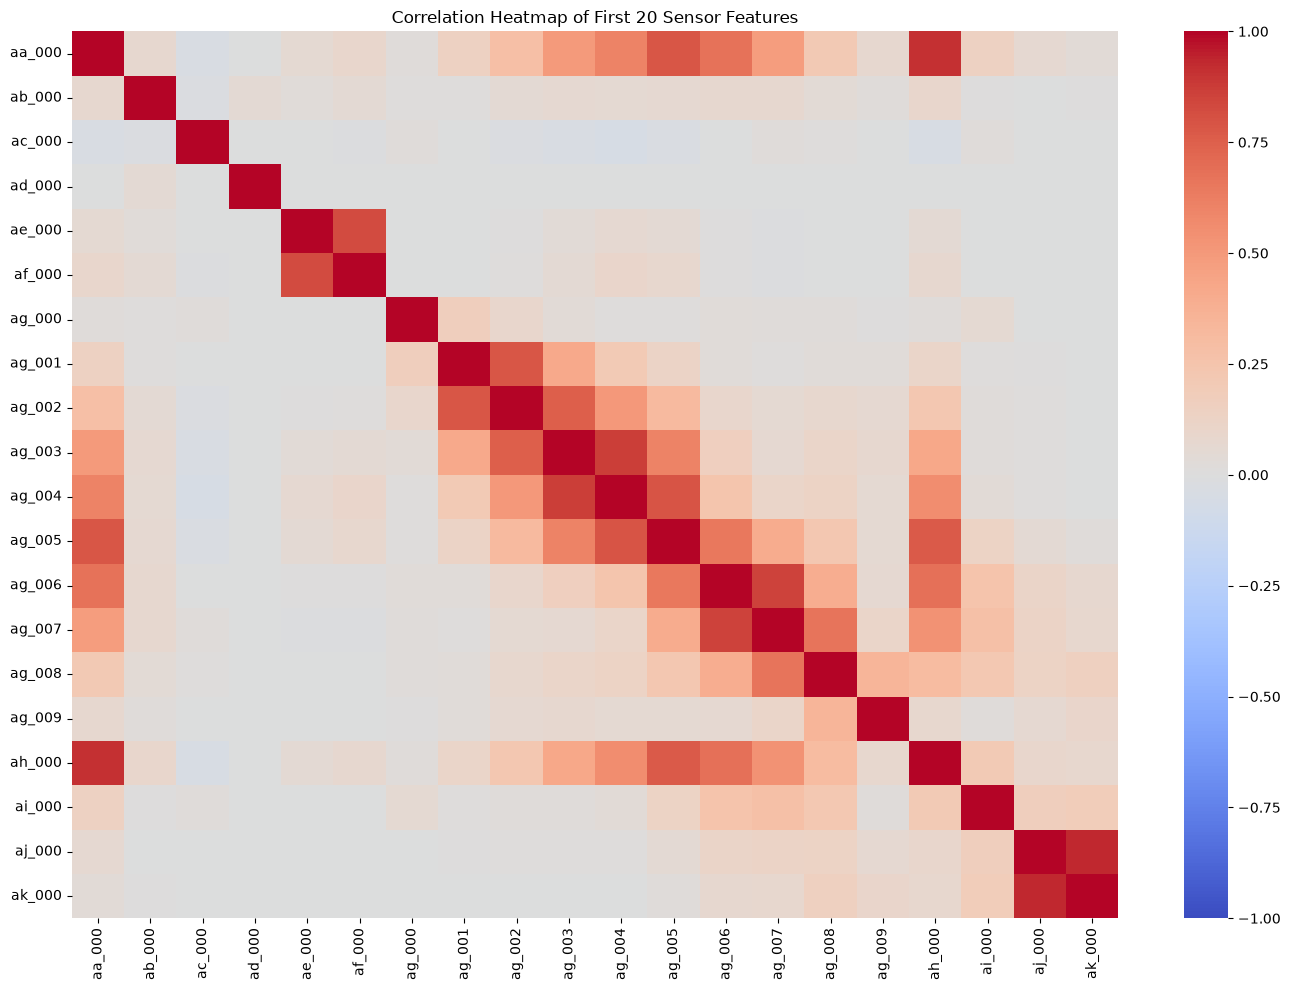

In [18]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix.iloc[:20, :20],
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of First 20 Sensor Features")
plt.tight_layout()
plt.show()

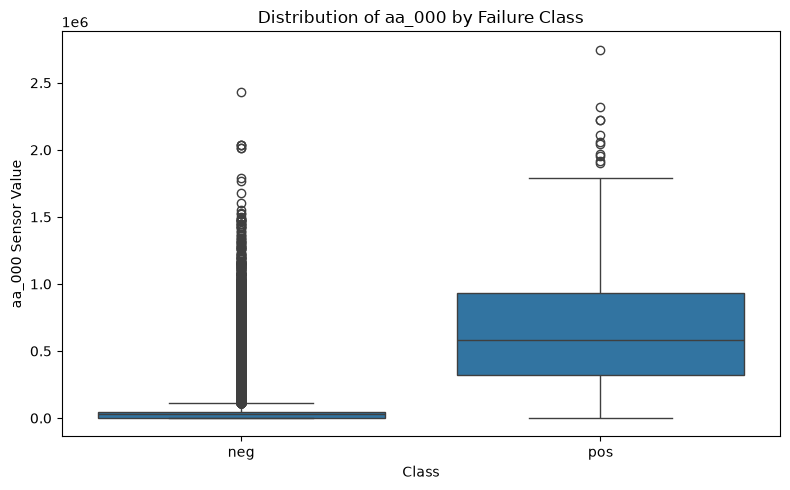

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="class",
    y="aa_000"
)

plt.title("Distribution of aa_000 by Failure Class")
plt.xlabel("Class")
plt.ylabel("aa_000 Sensor Value")

plt.tight_layout()
plt.show()

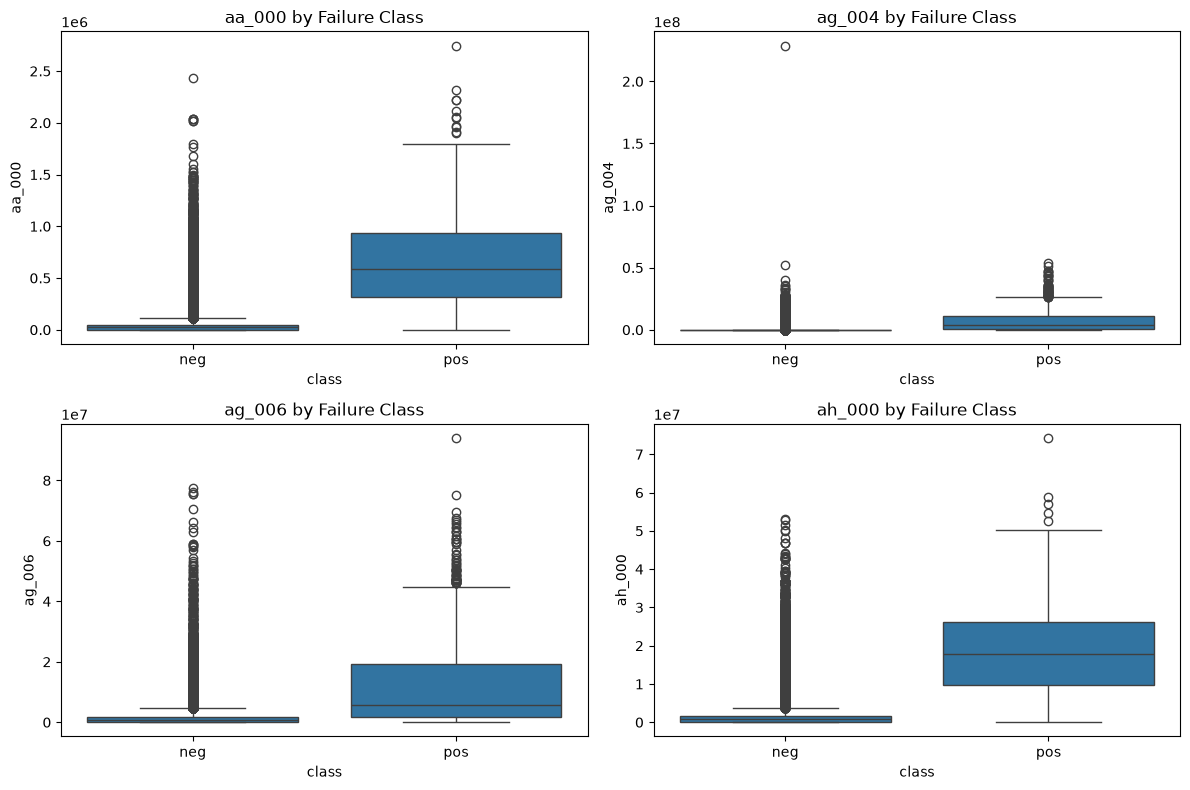

In [21]:
selected_features = ["aa_000", "ag_004", "ag_006", "ah_000"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for feature, ax in zip(selected_features, axes.flat):
    sns.boxplot(
        data=df,
        x="class",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Failure Class")

plt.tight_layout()
plt.show()

In [22]:
selected_features = ["aa_000", "ag_004", "ag_006", "ah_000"]

class_medians = df.groupby("class")[selected_features].median().T

print("Median sensor values by class:")
print(class_medians)

Median sensor values by class:
class        neg         pos
aa_000   30416.0    584994.0
ag_004    3424.0   3731539.0
ag_006  879046.0   5677782.0
ah_000  984519.0  17783922.0


In [23]:
median_ratios = (
    class_medians["pos"] / class_medians["neg"]
).sort_values(ascending=False)

print("Failure-to-non-failure median ratios:")
print(median_ratios.round(2))

Failure-to-non-failure median ratios:
ag_004    1089.82
aa_000      19.23
ah_000      18.06
ag_006       6.46
dtype: float64
